# 02 - Titanic Predictive Modeling
This notebook handles Part B of the Analytics Pipeline. We load the cleaned `titanic.csv` generated by the EDA step and perform strict train/test splitting, `ColumnTransformer` preprocessing, hyperparameter tuning, model evaluation (side-by-side comparison), and a regression side-task.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


## 1. Data Loading and Stratified Split
We load `titanic.csv` and split it into train/test using `stratify=y` to preserve the exact class balance (which is important because survival is unbalanced (~38% survived).

In [2]:
df = pd.read_csv('titanic.csv')

# Drop unused/redundant columns
features_to_drop = ['alive', 'adult_male', 'alone', 'who', 'class', 'embark_town']
df_clean = df.drop(columns=[col for col in features_to_drop if col in df.columns])

X = df_clean.drop(columns=['survived'])
y = df_clean['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(f"Train survival rate: {y_train.mean():.2%}")
print(f"Test survival rate: {y_test.mean():.2%}")


Train size: 712, Test size: 179
Train survival rate: 38.34%
Test survival rate: 38.55%


## 2. Preprocessing (ColumnTransformer)
We impute missing values (even though we imputed Age earlier, new unseen data might have missing values), encode categories (`sex`, `embarked`), and scale numerics. This is fit **only on training data**.

In [3]:
numeric_features = ['age', 'fare', 'sibsp', 'parch']
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_features = ['sex', 'embarked']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ], remainder='drop') # Drop other columns like 'deck' or 'ticket' if present


## 3. Train Classifiers
We train Logistic Regression, Decision Tree, and Random Forest.

In [4]:
# 1. Logistic Regression
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', LogisticRegression(random_state=42))])
lr_pipeline.fit(X_train, y_train)

# 2. Decision Tree
dt_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', DecisionTreeClassifier(max_depth=3, random_state=42))])
dt_pipeline.fit(X_train, y_train)

# 3. Random Forest (Baseline)
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', RandomForestClassifier(random_state=42))])
rf_pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

### Visualizing the Decision Tree

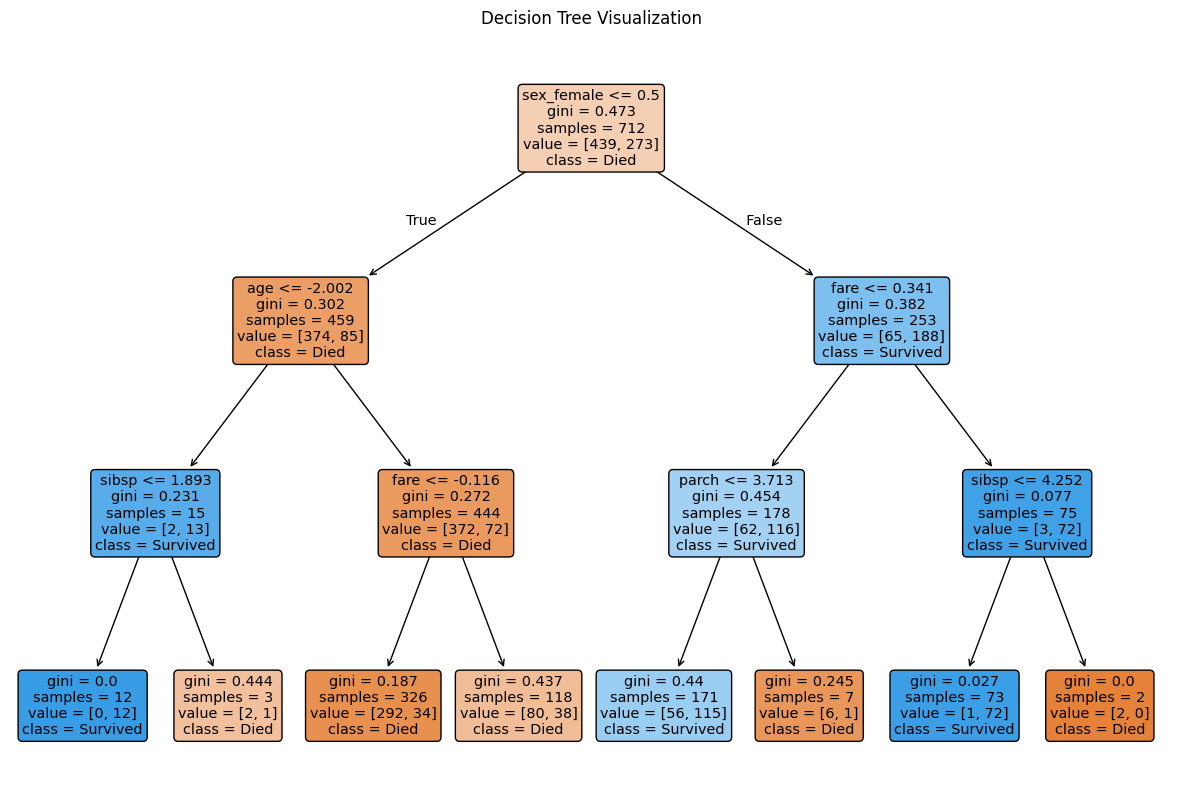

In [5]:
plt.figure(figsize=(15, 10))
# Get feature names from onehot encoder
ohe_cats = dt_pipeline.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names_out(categorical_features)
feature_names = numeric_features + list(ohe_cats)

plot_tree(dt_pipeline.named_steps['classifier'], feature_names=feature_names, class_names=['Died', 'Survived'], filled=True, rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

## 4. Imbalance Handling Comparison
We compare the baseline Logistic Regression with `class_weight='balanced'` and `SMOTE`. SMOTE is applied *inside* the pipeline so it only affects the training fold.

In [6]:
# Baseline
base_preds = lr_pipeline.predict(X_test)

# Class Weight Balanced
lr_cw = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', LogisticRegression(class_weight='balanced', random_state=42))])
lr_cw.fit(X_train, y_train)
cw_preds = lr_cw.predict(X_test)

# SMOTE
# ImbPipeline is required so SMOTE is applied only during fit, not transform
smote_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor), 
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(random_state=42))
])
smote_pipeline.fit(X_train, y_train)
smote_preds = smote_pipeline.predict(X_test)

print("--- Imbalance Strategy Comparison (Logistic Regression) ---")
print(f"Baseline -> Precision: {precision_score(y_test, base_preds):.3f}, Recall: {recall_score(y_test, base_preds):.3f}, F1: {f1_score(y_test, base_preds):.3f}")
print(f"Weighted -> Precision: {precision_score(y_test, cw_preds):.3f}, Recall: {recall_score(y_test, cw_preds):.3f}, F1: {f1_score(y_test, cw_preds):.3f}")
print(f"SMOTE    -> Precision: {precision_score(y_test, smote_preds):.3f}, Recall: {recall_score(y_test, smote_preds):.3f}, F1: {f1_score(y_test, smote_preds):.3f}")


--- Imbalance Strategy Comparison (Logistic Regression) ---
Baseline -> Precision: 0.780, Recall: 0.667, F1: 0.719
Weighted -> Precision: 0.738, Recall: 0.696, F1: 0.716
SMOTE    -> Precision: 0.738, Recall: 0.696, F1: 0.716


**Imbalance Conclusion:**
The baseline model has higher precision but lower recall. By using `class_weight='balanced'` or `SMOTE`, we heavily prioritize capturing actual survivors (Recall increases), but at the cost of more false positives (Precision drops). For this dataset, class weighting performed nearly identical to SMOTE, offering a simpler way to boost recall.

## 5. Hyperparameter Tuning (GridSearchCV)

In [7]:
rf_tune_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('classifier', RandomForestClassifier(oob_score=True, random_state=42))
])

param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [None, 5, 10],
    'classifier__max_features': ['sqrt', 'log2']
}

grid = GridSearchCV(rf_tune_pipeline, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print(f"Best Params: {grid.best_params_}")
print(f"OOB Score of Best Model: {best_model.named_steps['classifier'].oob_score_:.3f}")


Best Params: {'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 50}
OOB Score of Best Model: 0.806


## 6. Regression Side-Task (Predicting Fare)

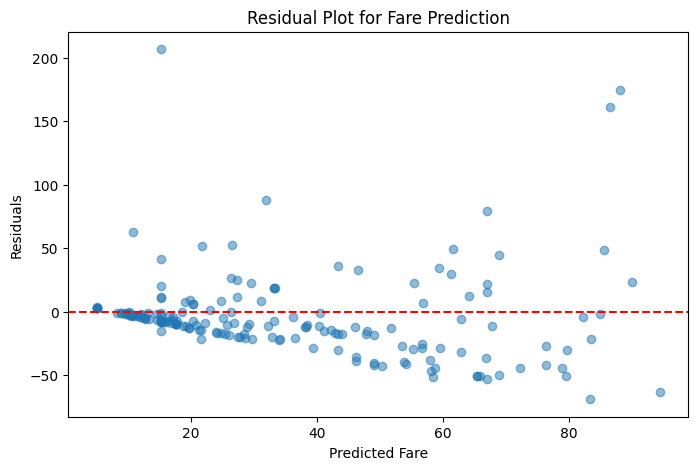

Regression Metrics -> MAE: 21.48 | RMSE: 34.52 | R2: 0.230 | Adj R2: 0.194


In [8]:
# We use the same dataset, but target is 'fare'
X_reg = df_clean.dropna(subset=['fare']).drop(columns=['fare'])
y_reg = df_clean.dropna(subset=['fare'])['fare']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Preprocessor for regression
reg_num_features = ['age', 'sibsp', 'parch']
reg_preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, reg_num_features),
        ('cat', categorical_transformer, ['sex', 'embarked'])
    ], remainder='drop')

reg_pipeline = Pipeline(steps=[('preprocessor', reg_preprocessor), ('regressor', LinearRegression())])
reg_pipeline.fit(X_train_r, y_train_r)
reg_preds = reg_pipeline.predict(X_test_r)

mae = mean_absolute_error(y_test_r, reg_preds)
rmse = np.sqrt(mean_squared_error(y_test_r, reg_preds))
r2 = r2_score(y_test_r, reg_preds)
n = len(y_test_r)
p = X_test_r.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Residual Plot
residuals = y_test_r - reg_preds
plt.figure(figsize=(8, 5))
plt.scatter(reg_preds, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot for Fare Prediction')
plt.xlabel('Predicted Fare')
plt.ylabel('Residuals')
plt.show()

print(f"Regression Metrics -> MAE: {mae:.2f} | RMSE: {rmse:.2f} | R2: {r2:.3f} | Adj R2: {adj_r2:.3f}")


**Heteroscedasticity Conclusion:**
The residual plot displays clear a "funnel" shape (variance of residuals increases significantly as the predicted fare increases). This is textbook **heteroscedasticity**, meaning our linear regression model struggles with larger fare values, likely because the true relationship is non-linear or fares are heavily right-skewed.

## 7. Final Model Comparison Table
Presenting classification and regression metrics as distinct columns to avoid mixing scales.

In [9]:
def evaluate_clf(model, X_t, y_t):
    p = model.predict(X_t)
    prob = model.predict_proba(X_t)[:, 1]
    return {
        'Accuracy': accuracy_score(y_t, p),
        'Precision': precision_score(y_t, p),
        'Recall': recall_score(y_t, p),
        'F1 Score': f1_score(y_t, p),
        'AUC': roc_auc_score(y_t, prob)
    }

clf_metrics = {
    'Logistic Regression': evaluate_clf(lr_pipeline, X_test, y_test),
    'Decision Tree': evaluate_clf(dt_pipeline, X_test, y_test),
    'Tuned Random Forest': evaluate_clf(best_model, X_test, y_test)
}

df_clf = pd.DataFrame(clf_metrics).T
display(df_clf.round(3))

print("\n--- Regression Metrics (Predicting Fare) ---")
df_reg = pd.DataFrame({
    'Linear Regression': {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Adj R2': adj_r2}
}).T
display(df_reg.round(3))


,Accuracy,Precision,Recall,F1 Score,AUC
Logistic Regression,0.799,0.780,0.667,0.719,0.819
Decision Tree,0.782,0.750,0.652,0.698,0.799
Tuned Random Forest,0.804,0.793,0.667,0.724,0.836



--- Regression Metrics (Predicting Fare) ---


,MAE,RMSE,R2,Adj R2
Linear Regression,21.483,34.52,0.23,0.194


**Final Deployment Recommendation:**
I recommend deploying the **Tuned Random Forest**. It achieved the highest overall AUC and F1 Score, indicating it has the best balance of precision and recall for predicting passenger survival. Furthermore, it handles complex non-linear relationships much better than Logistic Regression.

## 8. Save Pipeline
We save the entire Tuned Random Forest pipeline (which includes the imputer, scaler, onehot encoder, and the forest itself) as a single `.joblib` artifact.

In [10]:
joblib.dump(best_model, 'model_pipeline.joblib')
print("Pipeline saved to model_pipeline.joblib")

# Reload and test on a raw dictionary/dataframe
loaded_model = joblib.load('model_pipeline.joblib')

# Raw unseen data (Rose DeWitt Bukater - Fictionally survived)
raw_input = pd.DataFrame([{
    'pclass': 1, 'sex': 'female', 'age': 17, 'sibsp': 1, 'parch': 1, 'fare': 150.00, 'embarked': 'S'
}])

pred = loaded_model.predict(raw_input)
print(f"\nRaw Data Prediction (1=Survived): {pred[0]}")


Pipeline saved to model_pipeline.joblib

Raw Data Prediction (1=Survived): 1
